# MLP Training — Credit Risk Default Prediction

Binary classification with PyTorch. Class imbalance handled via `pos_weight` in BCE loss.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, RocCurveDisplay,
    precision_score, recall_score, f1_score
)
import mlflow

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [20]:
# Local environment — reads from ../../data/processed/
DATA_PATH = "/home/momo/Documents/internship/week-03/credit-risk-pipeline/data/processed"
OUT_DIR = "/home/momo/Documents/internship/week-03/credit-risk-pipeline/data-mining/building-nns/output/vanilla"
import os
os.makedirs(OUT_DIR, exist_ok=True)
print(f"DATA_PATH: {DATA_PATH}")
print(f"OUT_DIR:   {OUT_DIR}")


DATA_PATH: /home/momo/Documents/internship/week-03/credit-risk-pipeline/data/processed
OUT_DIR:   /home/momo/Documents/internship/week-03/credit-risk-pipeline/data-mining/building-nns/output/vanilla


In [21]:
# =============================================================================
# MLflow — experiment tracking (Docker server)
# =============================================================================
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("credit-risk-default")


run = mlflow.start_run(run_name="focal-mlp-tuned")
print(f"MLflow run: {run.info.run_id[:8]}...  |  tracking: http://localhost:5000")

MLflow run: fcf204b5...  |  tracking: http://localhost:5000


In [22]:
# --- Load processed data ---
train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
val_df   = pd.read_csv(f"{DATA_PATH}/val.csv")
test_df  = pd.read_csv(f"{DATA_PATH}/test.csv")

# Combine train + val for K-Fold CV
full_train_df = pd.concat([train_df, val_df], ignore_index=True)
X_full = full_train_df.drop(columns=['DEFAULT_OCT']).values.astype(np.float32)
y_full = full_train_df['DEFAULT_OCT'].values.astype(np.float32)

X_test = test_df.drop(columns=['DEFAULT_OCT']).values.astype(np.float32)
y_test = test_df['DEFAULT_OCT'].values.astype(np.float32)

print(f"Full train (for CV): {X_full.shape[0]:,} samples, {X_full.shape[1]} features")
print(f"Test:               {X_test.shape[0]:,} samples")
print(f"Default rate: {y_full.mean():.4f}")

Full train (for CV): 25,500 samples, 10 features
Test:               4,500 samples
Default rate: 0.2212


In [23]:
# --- PyTorch Dataset (on combined data) ---
class CreditRiskDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

input_dim = X_full.shape[1]
print(f"Input dimension: {input_dim}")

Input dimension: 10


In [24]:
# --- MLP Model ---
class CreditRiskMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32, 16], dropout_rates=[0.3, 0.3, 0.2]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hd, dr in zip(hidden_dims, dropout_rates):
            layers.append(nn.Linear(prev_dim, hd))
            layers.append(nn.BatchNorm1d(hd))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dr))
            prev_dim = hd
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(prev_dim, 1)

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(-1)

In [25]:
# =============================================================================
# Focal Loss — penalises minority-class mispredictions
# =============================================================================
#   FL(p_t) = -α_t · (1 - p_t)^γ · log(p_t)
#
#  α (alpha): class weight — up-weights the minority class
#  γ (gamma): focusing parameter — keeps loss high for confidently-wrong predictions
#
# A true defaulter predicted at 5% probability gets MUCH higher loss than
# one at 70%. The model can't coast on easy majority-class examples.

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.78, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)       # p of the TRUE class
        focal_weight = (1 - p_t) ** self.gamma              # down-weight easy examples
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * focal_weight * bce).mean()

In [26]:
# =============================================================================
# Best hyperparameters from Optuna tuning (Colab, 30 trials)
# Best val AUC: 0.7715
# =============================================================================
BEST_PARAMS = {
    'architecture': 'small',
    'dropout_0': 0.21826621192009288,
    'dropout_1': 0.3, #0.49736013564494147
    'dropout_2': 0.07778407548522404,
    'lr': 0.002120713876832468,
    'weight_decay': 5.037803800255336e-06,
    'focal_alpha': 0.78, #0.6834709085600853
    'focal_gamma': 2.0, #3.649519588137852
    'batch_size': 128,
}
print("✓ Using Colab-tuned hyperparameters (val AUC: 0.7715)")

# Log to MLflow
mlflow.log_params(BEST_PARAMS)

✓ Using Colab-tuned hyperparameters (val AUC: 0.7715)


In [27]:
# =============================================================================
# Model factory — build a fresh model from BEST_PARAMS
# =============================================================================
def build_model():
    arch_map = {
        'small': [64, 32, 16], 'medium': [128, 64, 32],
        'wide': [256, 128],    'deep': [128, 64, 32, 16],
    }
    best_hidden = arch_map[BEST_PARAMS['architecture']]
    n_layers = len(best_hidden)
    best_dropout = [BEST_PARAMS[f'dropout_{i}'] for i in range(n_layers)]
    
    model = CreditRiskMLP(input_dim, best_hidden, best_dropout).to(device)
    criterion = FocalLoss(
        alpha=BEST_PARAMS['focal_alpha'],
        gamma=BEST_PARAMS['focal_gamma']
    )
    optimizer = optim.Adam(
        model.parameters(),
        lr=BEST_PARAMS['lr'],
        weight_decay=BEST_PARAMS['weight_decay']
    )
    return model, criterion, optimizer

# Quick test
m, _, _ = build_model()
print(f"Arch: [64,32,16]  |  Params: {sum(p.numel() for p in m.parameters()):,}  |  "
      f"lr={BEST_PARAMS['lr']:.2e}  |  gamma={BEST_PARAMS['focal_gamma']:.2f}")

Arch: [64,32,16]  |  Params: 3,553  |  lr=2.12e-03  |  gamma=2.00


# 5-Fold Cross-Validation — stable OOF AUC estimates, comparable to ensemble

In [30]:
# =============================================================================
# 5-Fold CV — OOF predictions
# =============================================================================
N_FOLDS = 5
BATCH_SIZE = BEST_PARAMS['batch_size']
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_probs  = np.zeros(X_full.shape[0])
oof_labels = np.zeros(X_full.shape[0])

for fold_idx, (train_idx, oof_idx) in enumerate(skf.split(X_full, y_full)):
    print(f"Fold {fold_idx + 1}/{N_FOLDS}...", end=" ")
    
    X_tr, y_tr = X_full[train_idx], y_full[train_idx]
    X_oof, y_oof = X_full[oof_idx], y_full[oof_idx]
    
    # Carve out 15% val from train for early stopping
    X_ftr, X_fval, y_ftr, y_fval = train_test_split(
        X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=42 + fold_idx
    )
    
    model, criterion, optimizer = build_model()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    train_ds = CreditRiskDataset(X_ftr, y_ftr)
    val_ds   = CreditRiskDataset(X_fval, y_fval)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    
    best_val_loss = float('inf')
    best_state = None
    counter = 0
    
    for epoch in range(100):
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item() * Xb.size(0)
        val_loss /= len(val_ds)
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
        if counter >= 20:
            break
    
    model.load_state_dict(best_state)
    model.eval()
    
    oof_ds = CreditRiskDataset(X_oof, y_oof)
    oof_loader = DataLoader(oof_ds, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        probs_list=[]
        for Xb, _ in oof_loader:
            Xb = Xb.to(device)
            probs_list.append(torch.sigmoid(model(Xb)).cpu().numpy())
        oof_probs[oof_idx] = np.concatenate(probs_list)    
    fold_auc = roc_auc_score(y_oof, oof_probs[oof_idx])
    print(f"OOF AUC = {fold_auc:.4f}")
    mlflow.log_metric(f'cv_fold_{fold_idx+1}_auc', fold_auc)

oof_labels = y_full
cv_auc = roc_auc_score(oof_labels, oof_probs)
print(f"\n5-Fold CV OOF AUC: {cv_auc:.4f}")
# print(f"Fold AUCs: {[round(roc_auc_score(y_full[skf.split(X_full,y_full)][1], oof_probs[skf.split(X_full,y_full)][1]),4) for _ in range(N_FOLDS)]}")
mlflow.log_metric('cv_oof_auc', cv_auc)

Fold 1/5... OOF AUC = 0.7761
Fold 2/5... OOF AUC = 0.7872
Fold 3/5... OOF AUC = 0.7799
Fold 4/5... OOF AUC = 0.7703
Fold 5/5... OOF AUC = 0.7738

5-Fold CV OOF AUC: 0.7769


In [31]:
# =============================================================================
# Retrain final model on full training set
# =============================================================================
print("Retraining on full (train+val)...", end=" ")

# Carve out 10% val from full for early stopping
X_ftr, X_fval, y_ftr, y_fval = train_test_split(
    X_full, y_full, test_size=0.10, stratify=y_full, random_state=42
)

model, criterion, optimizer = build_model()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

train_ds = CreditRiskDataset(X_ftr, y_ftr)
val_ds   = CreditRiskDataset(X_fval, y_fval)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

best_val_loss = float('inf')
best_epoch = 0
counter = 0

for epoch in range(1, 101):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            val_loss += criterion(model(Xb), yb).item() * Xb.size(0)
    val_loss /= len(val_ds)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), f"{OUT_DIR}/best_model.pt")
        counter = 0
    else:
        counter += 1
    if counter >= 20:
        break

print(f"Best epoch {best_epoch}  |  val_loss: {best_val_loss:.4f}")

Retraining on full (train+val)... Best epoch 35  |  val_loss: 0.0490


In [32]:
# =============================================================================
# Standardised Evaluation — threshold=0.5 & max-F1 threshold
# =============================================================================
model.load_state_dict(torch.load(f"{OUT_DIR}/best_model.pt", weights_only=True))
model.eval()

# Test loader
test_ds = CreditRiskDataset(X_test, y_test)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

all_probs, all_labels = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits = model(Xb)
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# --- Threshold = 0.5 ---
preds_05 = (all_probs >= 0.5).astype(int)
auc   = roc_auc_score(all_labels, all_probs)
ap    = average_precision_score(all_labels, all_probs)
brier = brier_score_loss(all_labels, all_probs)
prec_05 = precision_score(all_labels, preds_05)
rec_05  = recall_score(all_labels, preds_05)
f1_05   = f1_score(all_labels, preds_05)

# --- Max-F1 threshold ---
from sklearn.metrics import precision_recall_curve
prec_curve, rec_curve, thresh = precision_recall_curve(all_labels, all_probs)
f1_curve = 2 * (prec_curve * rec_curve) / (prec_curve + rec_curve + 1e-10)
best_idx = np.argmax(f1_curve)
best_t   = thresh[best_idx]
preds_best = (all_probs >= best_t).astype(int)
prec_best = precision_score(all_labels, preds_best)
rec_best  = recall_score(all_labels, preds_best)
f1_best   = f1_score(all_labels, preds_best)

# --- Print ---
print(f"{'='*55}")
print(f"{'Metric':<20} {'thresh=0.5':>12} {'thresh='+f'{best_t:.2f}':>12}")
print(f"{'='*55}")
print(f"{'AUC-ROC':<20} {auc:>12.4f} {'—':>12}")
print(f"{'Avg Precision':<20} {ap:>12.4f} {'—':>12}")
print(f"{'Brier Score':<20} {brier:>12.4f} {'—':>12}")
print(f"{'Precision':<20} {prec_05:>12.4f} {prec_best:>12.4f}")
print(f"{'Recall':<20} {rec_05:>12.4f} {rec_best:>12.4f}")
print(f"{'F1':<20} {f1_05:>12.4f} {f1_best:>12.4f}")
print(f"{'='*55}")

# --- Log to MLflow ---
mlflow.log_metrics({
    'test_auc': auc, 'test_ap': ap, 'test_brier': brier,
    'test_precision_05': prec_05, 'test_recall_05': rec_05, 'test_f1_05': f1_05,
    'test_precision_best': prec_best, 'test_recall_best': rec_best, 'test_f1_best': f1_best,
    'test_threshold_best': best_t,
    'best_val_loss': best_val_loss, 'best_epoch': best_epoch,
})

Metric                 thresh=0.5  thresh=0.52
AUC-ROC                    0.7742            —
Avg Precision              0.5444            —
Brier Score                0.2071            —
Precision                  0.5004       0.5264
Recall                     0.5753       0.5612
F1                         0.5353       0.5432


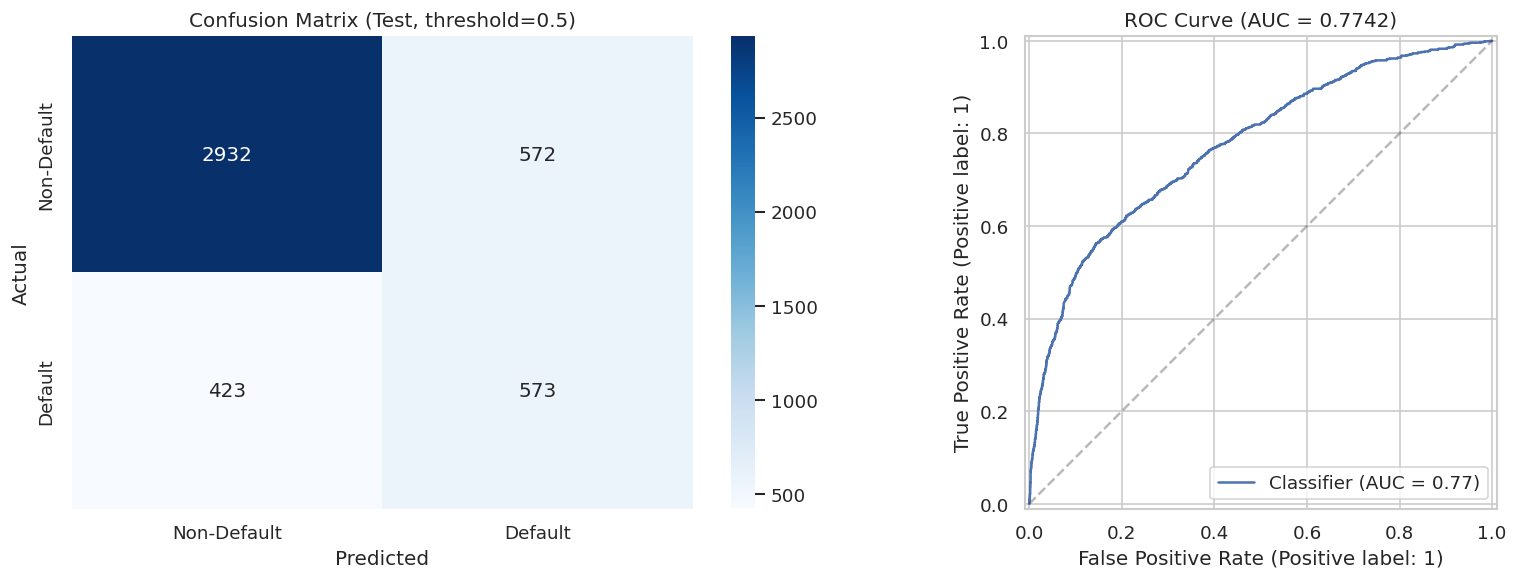

In [33]:
# --- Confusion Matrix & ROC Curve ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, preds_05)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix (Test, threshold=0.5)')

RocCurveDisplay.from_predictions(all_labels, all_probs, ax=ax2)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax2.set_title(f'ROC Curve (AUC = {auc:.4f})')

plt.tight_layout()
plt.show()

In [34]:
# --- Save results ---
pd.DataFrame({
    'auc_roc': [auc], 'ap': [ap], 'brier': [brier],
    'precision_05': [prec_05], 'recall_05': [rec_05], 'f1_05': [f1_05],
    'precision_best': [prec_best], 'recall_best': [rec_best], 'f1_best': [f1_best],
    'best_threshold': [best_t],
    'best_val_loss': [best_val_loss], 'best_epoch': [best_epoch],
}).to_csv(f"{OUT_DIR}/results.csv", index=False)

torch.save(model.state_dict(), f"{OUT_DIR}/best_model.pt")

mlflow.log_artifact(f"{OUT_DIR}/best_model.pt")
mlflow.log_artifact(f"{OUT_DIR}/results.csv")
mlflow.end_run()

print(f"Artifacts saved to {OUT_DIR}/")

Artifacts saved to /home/momo/Documents/internship/week-03/credit-risk-pipeline/data-mining/building-nns/output/vanilla/


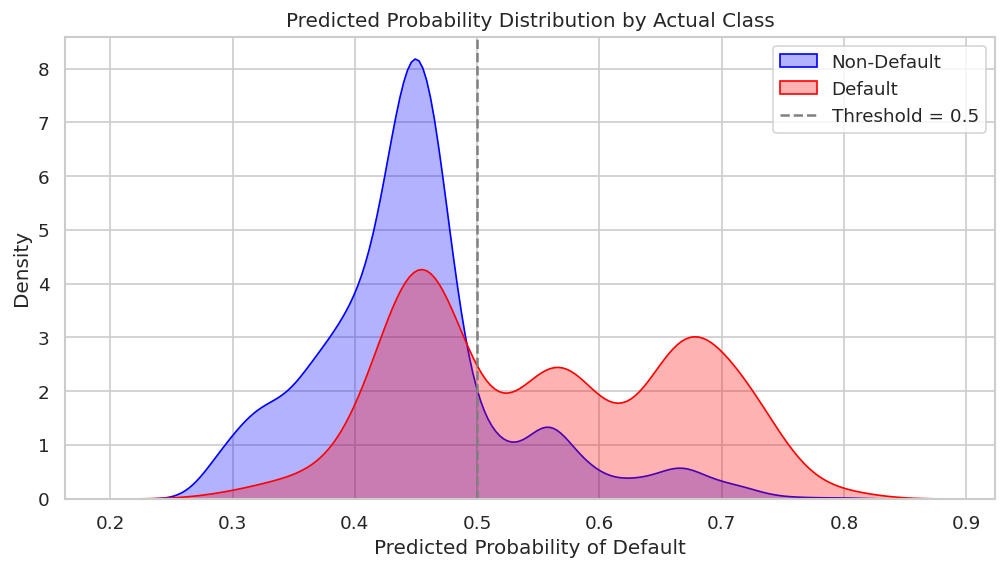

In [35]:
# --- Probability distribution by class ---
fig, ax = plt.subplots(figsize=(10, 5))

for label, color, name in [(0, 'blue', 'Non-Default'), (1, 'red', 'Default')]:
    mask = all_labels == label
    sns.kdeplot(all_probs[mask], fill=True, alpha=0.3, color=color, label=name, ax=ax)

ax.axvline(x=0.5, color='gray', linestyle='--', label='Threshold = 0.5')
ax.set_xlabel('Predicted Probability of Default')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by Actual Class')
ax.legend()
plt.show()